# Brusselator Reaction-Diffusion System Analysis
This notebook analyzes the output data generated by the high-performance C++ Brusselator solver. The C++ solver computes the spatial discretization and implicit time integration and outputs the results as legacy ASCII VTK files and execution logs.

We use this notebook solely to load, process, and visualize the generated data from the `Work/results/` directory.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import glob

plt.rcParams.update({'font.size': 14})

# Ensure the figures directory exists
os.makedirs('figures', exist_ok=True)

## 1. Reading Legacy ASCII VTK Files
The C++ solver exports the 2D concentration fields $C_1$ and $C_2$ as structured grid points in a legacy VTK format. The following function parses these files manually without requiring external VTK libraries.

In [2]:
def read_vtk(filepath):
    """
    Reads a legacy ASCII VTK structured points file generated by the C++ solver.
    Returns the 2D numpy arrays for C1 and C2.
    """
    with open(filepath, 'r') as f:
        lines = f.readlines()
        
    # Parse dimensions
    dim_line = [l for l in lines if l.startswith("DIMENSIONS")][0]
    parts = dim_line.split()
    nx, ny = int(parts[1]), int(parts[2])
    N = nx * ny
    
    # Extract C1 scalar field
    c1_idx = next(i for i, l in enumerate(lines) if l.startswith("SCALARS C1")) + 2
    C1_flat = np.array([float(lines[i]) for i in range(c1_idx, c1_idx + N)])
    C1 = C1_flat.reshape((ny, nx))
    
    # Extract C2 scalar field
    c2_idx = next(i for i, l in enumerate(lines) if l.startswith("SCALARS C2")) + 2
    C2_flat = np.array([float(lines[i]) for i in range(c2_idx, c2_idx + N)])
    C2 = C2_flat.reshape((ny, nx))
    
    return C1, C2

## 2. Parameter Variation 1: Pattern Formation (Turing Bifurcation)
We load the final time step output (`output_0030.vtk`) for each value of $C_b \in \{1.5, 2.0, 2.5, 3.0\}$ and plot the concentration field $C_1$.

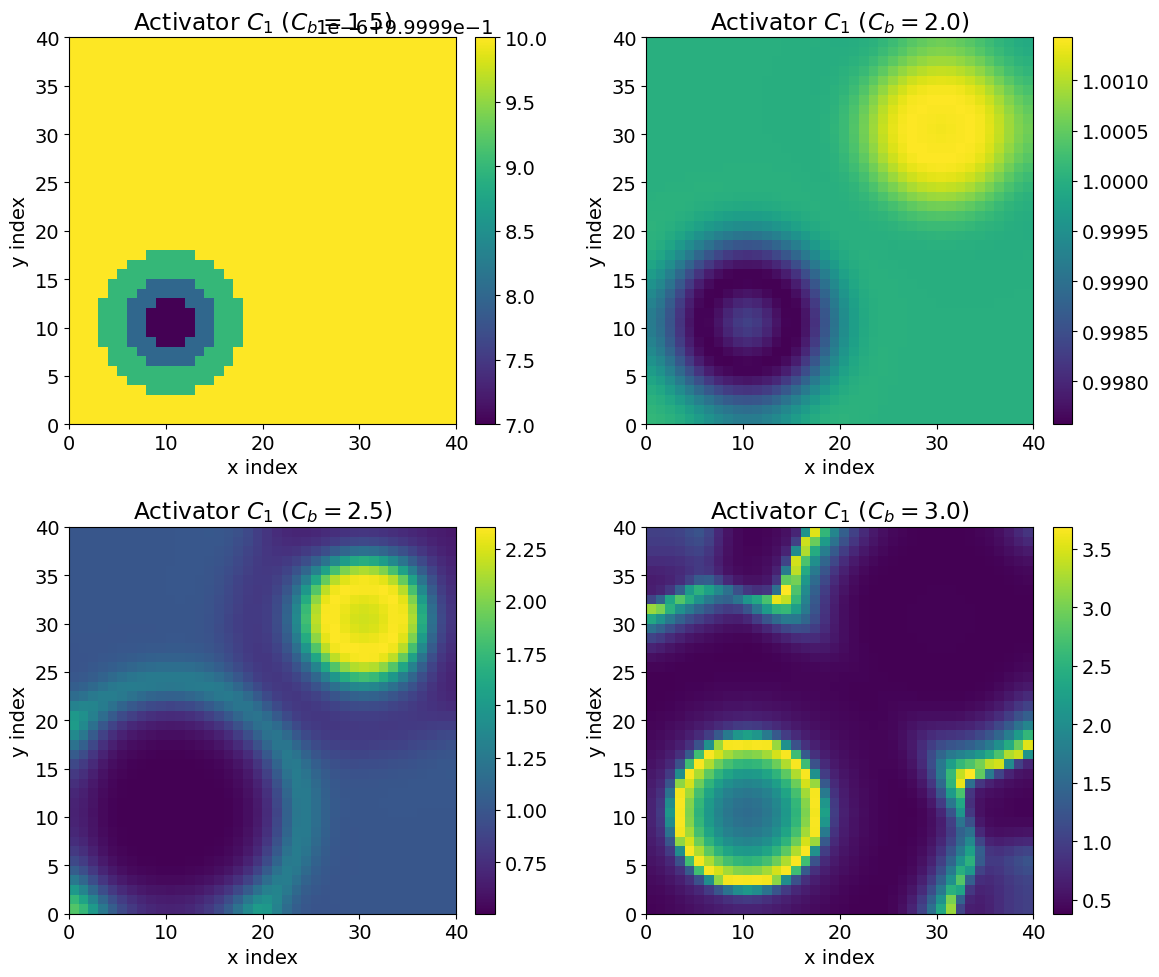

In [3]:
def plot_turing_patterns():
    cb_values = [1.5, 2.0, 2.5, 3.0]
    
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    axes = axes.flatten()
    
    for i, cb in enumerate(cb_values):
        # Check if the output file exists
        vtk_file = f"Work/results/var1/run_{cb}/output_0030.vtk"
        if not os.path.exists(vtk_file):
            print(f"Warning: {vtk_file} not found. Please run the C++ solver script first.")
            continue
            
        C1, C2 = read_vtk(vtk_file)
        
        ax = axes[i]
        im = ax.imshow(C1, cmap='viridis', origin='lower', extent=[0, 40, 0, 40])
        ax.set_title(f"Activator $C_1$ ($C_b = {cb}$)")
        ax.set_xlabel("x index")
        ax.set_ylabel("y index")
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        
        # Save individual plots for LaTeX report
        plt.figure()
        plt.imshow(C1, cmap='viridis', origin='lower', extent=[0, 40, 0, 40])
        plt.title(f"Activator $C_1$ ($C_b = {cb}$)")
        plt.xlabel("x index")
        plt.ylabel("y index")
        plt.colorbar(fraction=0.046, pad=0.04)
        plt.savefig(f"figures/pattern_cb{cb}.png", dpi=300, bbox_inches='tight')
        plt.close()
        
    fig.tight_layout()
    plt.show()

plot_turing_patterns()

## 3. Parsing Log Files for Convergence Analysis
To analyze the convergence of the Inexact Newton solver (Implicit Euler method), we parse the stdout logs saved in `simulation.log` to extract the number of Newton iterations required at each time step.

In [4]:
def read_log(filepath):
    """
    Parses the simulation.log file to extract the times and corresponding Newton iterations.
    """
    times = []
    iterations = []
    
    with open(filepath, 'r') as f:
        for line in f:
            if "Newton Iterations:" in line and "|" in line:
                # Example line: Time: 0.100 s | Step: 10 | Newton Iterations: 2
                parts = line.split("|")
                t_str = parts[0].strip().replace("Time: ", "").replace(" s", "")
                iter_str = parts[2].strip().replace("Newton Iterations: ", "")
                
                times.append(float(t_str))
                iterations.append(int(iter_str))
                
    return times, iterations

## 4. Parameter Variation 2: Newton Iterations over Time
We load the logs for varying time-step sizes $\Delta t \in \{0.01, 0.02, 0.03, 0.04, 0.05\}$ and plot the iteration count.

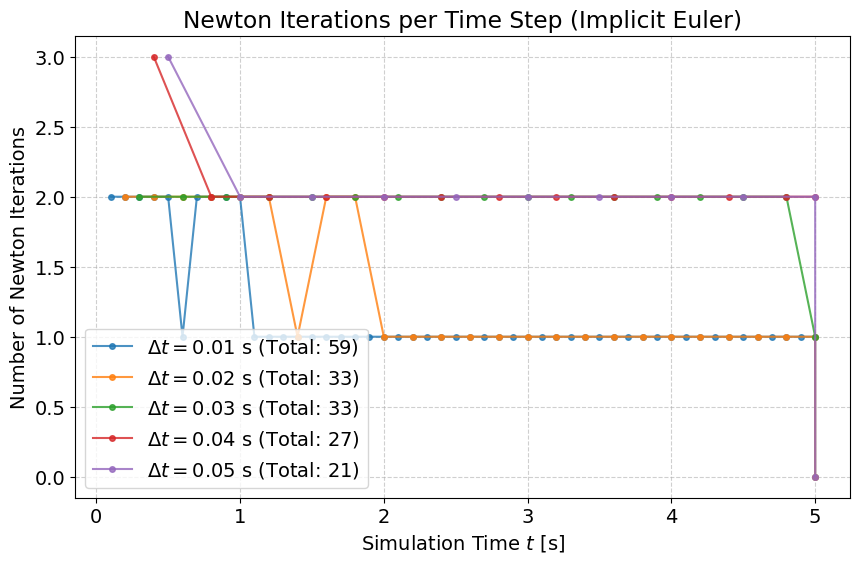

In [5]:
def plot_newton_convergence():
    dt_values = [0.01, 0.02, 0.03, 0.04, 0.05]
    
    plt.figure(figsize=(10, 6))
    
    for dt in dt_values:
        log_file = f"Work/results/var2/run_{dt}/simulation.log"
        if not os.path.exists(log_file):
            print(f"Warning: {log_file} not found. Please run the C++ solver script first.")
            continue
            
        times, iterations = read_log(log_file)
        total_its = sum(iterations)
        
        plt.plot(times, iterations, label=fr"$\Delta t = {dt}$ s (Total: {total_its})", 
                 marker='o', markersize=4, alpha=0.8)
        
    plt.title("Newton Iterations per Time Step (Implicit Euler)")
    plt.xlabel("Simulation Time $t$ [s]")
    plt.ylabel("Number of Newton Iterations")
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()
    
    # Save for LaTeX report
    plt.savefig("figures/newton_iterations.png", dpi=300, bbox_inches='tight')
    plt.show()

plot_newton_convergence()

In [6]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import glob

# 1. Get all VTK files for a specific run and sort them
vtk_files = sorted(glob.glob('Work/results/var1/run_1.5/output_*.vtk'))

# 2. Set up the figure and axis
fig, ax = plt.subplots(figsize=(6, 6))

# Read the first frame to initialize the plot
C1, C2 = read_vtk(vtk_files[0])
im = ax.imshow(C1, cmap='viridis', origin='lower', vmin=0, vmax=5) # Adjust vmin/vmax based on your data range
ax.set_title("Brusselator C1 - Frame 0")
ax.axis('off')

# 3. Define the update function for the animation
def update(frame):
    # Read the data for the current frame
    C1, C2 = read_vtk(vtk_files[frame])
    im.set_data(C1)
    # Automatically adjust color limits if needed, or rely on fixed vmin/vmax
    im.set_clim(C1.min(), C1.max()) 
    ax.set_title(f"Brusselator C1 - Frame {frame}")
    return [im]

# 4. Create the animation
ani = FuncAnimation(fig, update, frames=len(vtk_files), blit=True, interval=100)

# Prevent the static initial frame from displaying below the animation
plt.close(fig) 

# 5. Display the animation as an interactive HTML widget in the notebook
HTML(ani.to_jshtml())


In [ ]:
# Save as a GIF
ani.save('figures/brusselator_animation.gif', writer='pillow', fps=10)

# Save as an MP4 (requires ffmpeg)
# ani.save('figures/brusselator_animation.mp4', writer='ffmpeg', fps=10)
